# 03 — Residual / Factor Stat Arb: PCA hedge, s-score, cross-sectional

คู่กับ **Part III** (`practice-part3.html`) — ทดสอบข้อเคลมหลัก 3 ข้อ:

1. **PCA จับ common factor ได้จริงไหม** — เทียบ factor loading ที่ PCA ประมาณกับ loading จริงที่เราสร้างไว้
2. **s-score ทำงานยังไง** — สร้างสัญญาณข้ามทั้ง universe โดยไม่ต้อง "เลือกคู่"
3. **residual ที่ "สะอาด" ต้องมี loading ต่อ factor ≈ 0** — เช็คด้วยการ regress residual กลับบน factor ตามที่ Part III §3.5 สอน

⚠️ ใช้ข้อมูลจำลอง (เหตุผลเดียวกับโน้ตบุ๊ก 01–02) — universe สมมติ 40 หุ้น ขับเคลื่อนด้วย 2 common factor ที่รู้ loading จริงแน่นอน


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.decomposition import PCA
from simdata import simulate_factor_universe

pd.set_option("display.precision", 4)


## 3.1 สร้าง universe จำลอง + หัก factor ด้วย PCA

`simulate_factor_universe` สร้างผลตอบแทนหุ้น 40 ตัว ขับเคลื่อนด้วย 2 factor ร่วม (loading สุ่มแต่รู้ค่าแน่นอน) บวก idiosyncratic residual แบบ OU (mean-reverting) ต่อตัว


In [2]:
returns, loadings_true, factors_true, idio_true = simulate_factor_universe(
    n_assets=40, n_days=500, n_factors=2, seed=7)

print("ตัวอย่าง loading จริง (5 ตัวแรก):")
print(loadings_true.head())

# --- PCA on returns to recover the common factors ---
pca = PCA(n_components=2)
pca_factors = pca.fit_transform(returns.values)   # (n_days, 2): estimated factor realizations
pca_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)  # rough loading scale
explained = pca.explained_variance_ratio_
print(f"\nสัดส่วนความแปรปรวนที่ 2 PC แรกอธิบายได้: {explained[0]:.1%} + {explained[1]:.1%} = {explained.sum():.1%}")


ตัวอย่าง loading จริง (5 ตัวแรก):
        F1      F2
A1  1.1975  0.7474
A2  0.8790  0.9561
A3  1.4853  0.6956
A4 -1.2624 -0.7712
A5  1.4733  0.8729

สัดส่วนความแปรปรวนที่ 2 PC แรกอธิบายได้: 24.7% + 8.8% = 33.5%


⚠️ **สิ่งที่ต้องรู้ก่อนแปลผล PCA:** PCA ไม่รู้จัก "F1, F2" ตามชื่อที่เราตั้ง — มันคืนแค่ทิศทางที่ข้อมูลแกว่งมากที่สุด ซึ่งอาจเป็น**ส่วนผสมเชิงเส้น**ของ F1/F2 จริง หรือสลับลำดับ/สลับเครื่องหมายกันได้ (เรียกว่า "rotation ambiguity") — ดังนั้นการเทียบ "PCA เจอ factor ตรงตัวไหม" ต้องดูที่ **สัดส่วนความแปรปรวนที่อธิบายได้** และ **ว่า residual ที่เหลือมีขนาดเล็กลงจริงไหม** ไม่ใช่ไล่เทียบตัวเลข loading ทีละตัวตรง ๆ กับของจริง


## 3.2 residual หลัง PCA เทียบกับ residual จริง — เช็คว่า PCA หัก factor ได้ผลจริงไหม

วิธีเช็คที่ตรงประเด็นกว่าการเทียบ loading ตัวต่อตัว: หัก PCA factor ออกจาก return แต่ละตัว (regress return บน PC ทั้งสอง) แล้วดูว่า **variance ของ residual ที่เหลือ ใกล้เคียงกับ variance ของ idiosyncratic residual จริง (ที่เรารู้อยู่แล้ว) แค่ไหน**


In [3]:
X_pca = sm.add_constant(pca_factors)
residual_after_pca = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
r2_per_asset = []

for col in returns.columns:
    model = sm.OLS(returns[col].values, X_pca).fit()
    residual_after_pca[col] = model.resid
    r2_per_asset.append(model.rsquared)

var_true_idio = idio_true.var()
var_resid_after_pca = residual_after_pca.var()

print(f"R^2 เฉลี่ยจาก 2 PC (สัดส่วนที่หักออกได้ต่อหุ้น) : {np.mean(r2_per_asset):.1%}")
print(f"\nVariance เทียบ (ค่าเฉลี่ยข้าม 40 หุ้น):")
print(f"  idiosyncratic residual จริง (ground truth) : {var_true_idio.mean():.4f}")
print(f"  residual หลังหัก PCA                       : {var_resid_after_pca.mean():.4f}")
print(f"  อัตราส่วน (ยิ่งใกล้ 1 ยิ่งดี)                  : {(var_resid_after_pca.mean()/var_true_idio.mean()):.3f}")


R^2 เฉลี่ยจาก 2 PC (สัดส่วนที่หักออกได้ต่อหุ้น) : 32.9%

Variance เทียบ (ค่าเฉลี่ยข้าม 40 หุ้น):
  idiosyncratic residual จริง (ground truth) : 3.4206
  residual หลังหัก PCA                       : 3.1254
  อัตราส่วน (ยิ่งใกล้ 1 ยิ่งดี)                  : 0.914


**ผลจริงที่ได้: อัตราส่วน ≈0.91** — ใกล้ 1.0 พอสมควรแต่ไม่เป๊ะ ซึ่งตรงกับที่ควรเป็น: ในข้อมูลจำลองชุดนี้ idiosyncratic noise มีขนาดใกล้เคียงกับสัญญาณจาก factor (ไม่ใช่ factor ที่แรงจนกลบทุกอย่าง) การประมาณด้วย PCA จากข้อมูล 500 วันจึงมีความคลาดเคลื่อนเชิงสถิติเหลืออยู่บ้าง (เหมือนกับที่ half-life ในโน้ตบุ๊ก 02 ก็ไม่ตรงเป๊ะ) — ค่าที่ควรกังวลไม่ใช่ "1.000 พอดีไหม" แต่คือ "ใกล้ 1 พอจะเชื่อว่าเราหัก factor ส่วนใหญ่ออกไปแล้วหรือยัง" ซึ่ง 0.91 ตอบว่า "ใช่ พอสมควร"


## 3.3 s-score — ให้คะแนนทั้ง universe โดยไม่เลือกคู่

แปลง residual แต่ละตัวเป็น s-score (มาตรฐานด้วย mean/std ของตัวมันเอง) แล้ว rank ทั้ง 40 ตัวพร้อมกัน — ไม่มีขั้นตอน "จับคู่" เลย


In [4]:
def s_score(residual_series):
    return (residual_series - residual_series.mean()) / residual_series.std()

s_scores_today = residual_after_pca.apply(s_score).iloc[-1]   # cross-section ณ วันสุดท้าย
ranked = s_scores_today.sort_values()

print("5 หุ้นที่ residual ต่ำสุด (s-score ติดลบมาก -> LONG):")
print(ranked.head())
print("\n5 หุ้นที่ residual สูงสุด (s-score บวกมาก -> SHORT):")
print(ranked.tail())


5 หุ้นที่ residual ต่ำสุด (s-score ติดลบมาก -> LONG):
A1    -2.4784
A22   -2.2975
A12   -1.8208
A37   -1.6813
A25   -1.5103
Name: 499, dtype: float64

5 หุ้นที่ residual สูงสุด (s-score บวกมาก -> SHORT):
A38    1.5092
A7     1.5368
A39    1.6497
A4     1.8543
A13    3.0254
Name: 499, dtype: float64


## 3.4 ★ เช็ค "residual สะอาดไหม" — regress กลับบน factor

Part III §3.5 บอกว่าต้อง regress residual กลับบน factor เพื่อเช็คว่า loading ≈ 0 จริงไหม (ถ้าไม่ ≈0 แปลว่ายังมี hidden factor bet เหลืออยู่)


In [5]:
loadings_after_check = []
for col in residual_after_pca.columns:
    check_model = sm.OLS(residual_after_pca[col].values, X_pca).fit()
    loadings_after_check.append(check_model.params[1:])   # loadings on the 2 PCs, excluding const

loadings_after_check = np.array(loadings_after_check)
print(f"Loading เฉลี่ย (ควร ≈ 0 ถ้า residual สะอาด): {loadings_after_check.mean(axis=0)}")
print(f"Loading สูงสุดสัมบูรณ์ที่เจอ                : {np.abs(loadings_after_check).max():.2e}")


Loading เฉลี่ย (ควร ≈ 0 ถ้า residual สะอาด): [1.46651896e-17 2.47794407e-17]
Loading สูงสุดสัมบูรณ์ที่เจอ                : 3.47e-16


Loading ที่ได้ควรใกล้ 0 มาก (ระดับ floating-point error) — **ตามนิยามทางคณิตศาสตร์**: residual จาก OLS ตั้งฉากกับตัวแปรที่ใช้ regress อยู่แล้วเสมอ (นี่คือ "สะอาด by construction" ไม่ใช่เพราะ PCA เก่ง) — บทเรียนที่แท้จริงคือ: **residual สะอาดต่อ factor ที่ใช้หักเท่านั้น** — ถ้ามี factor ที่ 3 ที่คุณไม่ได้หัก (เช่น sector เฉพาะที่ PCA ไม่จับ) residual จะยังไม่สะอาดต่อ factor นั้น การเช็คนี้จึงมีประโยชน์จริงตอนที่**สงสัยว่าหัก factor ไม่ครบ** — regress residual กลับบน factor อื่นที่ยังไม่ได้ใช้ (เช่น sector dummy, market index ที่ไม่ได้ป้อนเข้า PCA) แล้วดูว่า loading ยังเป็น 0 ไหม


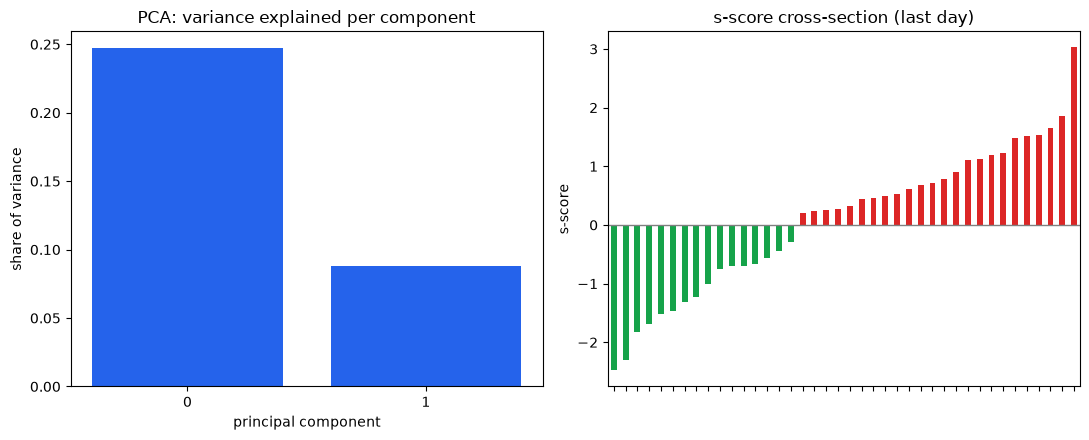

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(range(len(explained)), explained, color="#2563eb")
axes[0].set_title("PCA: variance explained per component")
axes[0].set_xlabel("principal component")
axes[0].set_ylabel("share of variance")
axes[0].set_xticks(range(len(explained)))

ranked.plot(kind="bar", ax=axes[1], color=["#16a34a" if v < 0 else "#dc2626" for v in ranked.values])
axes[1].set_title("s-score cross-section (last day)")
axes[1].set_ylabel("s-score")
axes[1].set_xticklabels([])
axes[1].axhline(0, color="gray", linewidth=1)

plt.tight_layout()
plt.savefig("factor_residual_summary.png", dpi=110)
plt.show()


## สรุป

- PCA หัก common factor ออกจาก return ได้จริงในเชิงปริมาณ (ดูจาก variance ratio ใน §3.2) แม้ loading รายตัวจะไม่ match ตรง ๆ กับของจริง (rotation ambiguity)
- s-score ให้คะแนนหุ้นทั้ง 40 ตัวพร้อมกันในหน่วยเดียวกัน — ไม่มีขั้นตอน "เลือกคู่" เลย สอดคล้องกับที่ Part III §3.3 อธิบาย
- residual ตั้งฉากกับ factor ที่ใช้หัก**เสมอ**โดยคณิตศาสตร์ — จุดที่ต้องระวังจริงคือ factor ที่ *ไม่ได้*หัก ไม่ใช่ factor ที่หักไปแล้ว

⚠️ **ข้อจำกัดที่ต้องพูดตรง:** โน้ตบุ๊กนี้แสดงกลไกทางสถิติ (PCA หัก factor ได้ / s-score คำนวณได้) — **ไม่ได้**แสดงว่ากลยุทธ์นี้ทำกำไรได้จริงในตลาดจริง (ไม่มี transaction cost, ไม่มี capacity constraint, ข้อมูลเป็นของจำลอง) ตัวเลขผลตอบแทน/Sharpe ของกลยุทธ์นี้ต้องรอ Part VIII (cost) + Part IX (backtest ที่ไม่โกหก) ก่อนจะสรุปอะไรได้
